# Stacking моделей инфляции

Для каждого горизонта используются 484 комбинации: 22 модели residual FEDFUNDS/PySR × 22 модели инфляции. Веса неотрицательны и дают единицу в сумме.

Ledoit–Wolf оценивает ковариацию ошибок. К ней добавляются квадрат смещения и ridge-регуляризация. Веса обучаются на in-sample прогнозах базовых моделей, поэтому train MSE оптимистичен; для строгого stacking нужны временные OOF-прогнозы всех базовых слоёв. `df_full` в подборе весов не участвует.

In [1]:
import json
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

# Берём точно ту же подготовку data/X, что и в infl_modls.ipynb, но не запускаем fit.
infl_nb = json.loads(Path('infl_modls.ipynb').read_text())
needed = ('import os', 'RATE_MODEL_DIR', 'def make_features', 'rate_features',
          'def pysr_inputs', 'BASE_FEATURES', 'import optuna', 'class GLSARRegressor')
for cell in infl_nb['cells']:
    source = ''.join(cell.get('source', []))
    if cell['cell_type'] == 'code' and source.lstrip().startswith(needed):
        exec(compile(source, 'infl_modls.ipynb', 'exec'))
del infl_nb, source

STACKING_DIR = Path('models/stacking'); STACKING_DIR.mkdir(parents=True, exist_ok=True)
LAMBDA = float(os.getenv('STACKING_LAMBDA', .01))
REFRESH_PREDICTIONS = os.getenv('REFRESH_STACKING_PREDICTIONS', '0') == '1'
assert len(ACTIVE_RATE_NAMES) * len(INFL_MODEL_NAMES) == 484
print(f'{len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} моделей инфляции = 484; lambda={LAMBDA}')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
22 residual-моделей × 22 моделей инфляции = 484; lambda=0.01


## Прогнозы 484 комбинаций



In [2]:
def make_prediction_matrices(h):
    train_pred, full_pred = {}, {}
    X_train, X_full = globals()[f'X_h{h}'], globals()[f'X_full_h{h}']
    for rate_name in ACTIVE_RATE_NAMES:
        for infl_name in INFL_MODEL_NAMES:
            key, model = f'{infl_name}|{rate_name}', load_model(infl_name, rate_name, h)
            train_pred[key] = pd.Series(model.predict(X_train[rate_name]), index=X_train[rate_name].index)
            full_pred[key] = pd.Series(model.predict(X_full[rate_name]), index=X_full[rate_name].index)
    return pd.DataFrame(train_pred).dropna(), pd.DataFrame(full_pred).dropna()

train_predictions, full_predictions = {}, {}
for h in range(1, 9):
    train_file, full_file = STACKING_DIR / f'train_predictions_h{h}.pkl', STACKING_DIR / f'full_predictions_h{h}.pkl'
    if train_file.exists() and full_file.exists() and not REFRESH_PREDICTIONS:
        train_predictions[h], full_predictions[h] = pd.read_pickle(train_file), pd.read_pickle(full_file)
    else:
        train_predictions[h], full_predictions[h] = make_prediction_matrices(h)
        train_predictions[h].to_pickle(train_file); full_predictions[h].to_pickle(full_file)
    print(f'h{h}: train={train_predictions[h].shape}, full={full_predictions[h].shape}')

h1: train=(65, 484), full=(75, 484)
h2: train=(63, 484), full=(74, 484)
h3: train=(61, 484), full=(73, 484)
h4: train=(59, 484), full=(72, 484)
h5: train=(57, 484), full=(71, 484)
h6: train=(55, 484), full=(70, 484)
h7: train=(53, 484), full=(69, 484)
h8: train=(51, 484), full=(68, 484)


## Веса минимального MSE

Если $E$ — матрица ошибок 484 моделей, то MSE ансамбля равен $w^T(\Sigma+\mu\mu^T)w$. Вместо нестабильной выборочной ковариации используется Ledoit–Wolf и добавляется $\lambda\lVert w\rVert^2$.

In [3]:
def minimum_mse_weights(predictions, target, lam=LAMBDA):
    y = target.reindex(predictions.index); valid = y.notna()
    P, y = predictions.loc[valid], y.loc[valid]
    errors = P.to_numpy() - y.to_numpy()[:, None]
    lw = LedoitWolf().fit(errors); mean_error = errors.mean(axis=0)
    second_moment = lw.covariance_ + np.outer(mean_error, mean_error)
    scale = max(np.trace(second_moment) / len(mean_error), 1e-12)
    Q = second_moment / scale + lam * np.eye(len(mean_error))
    w0 = np.full(len(mean_error), 1 / len(mean_error))
    result = minimize(lambda w: w @ Q @ w, w0, jac=lambda w: 2 * Q @ w, method='SLSQP',
                      bounds=[(0, 1)] * len(w0),
                      constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1,
                                   'jac': lambda w: np.ones_like(w)},
                      options={'ftol': 1e-12, 'maxiter': 2000})
    if not result.success: raise RuntimeError(result.message)
    weights = np.maximum(result.x, 0); weights /= weights.sum()
    return pd.Series(weights, index=P.columns), P, y, lw.shrinkage_

def save_weight_dict(h, weights):
    result = {name: float(value) for name, value in weights.items()}
    with (STACKING_DIR / f'stacking_weights_h{h}.pkl').open('wb') as file: cloudpickle.dump(result, file)
    with (STACKING_DIR / f'stacking_weights_h{h}.json').open('w') as file: json.dump(result, file, indent=2)
    return result

In [4]:
weights_by_h, train_rows = {}, []
for h in range(1, 9):
    weights, P, y, shrinkage = minimum_mse_weights(train_predictions[h], globals()[f'y_h{h}'])
    weights_by_h[h] = save_weight_dict(h, weights); globals()[f'weights_h{h}'] = weights_by_h[h]
    ensemble, equal = P @ weights, P.mean(axis=1)
    train_rows.append({'horizon': h, 'observations': len(y), 'nonzero_weights': int((weights > 1e-8).sum()),
                       'ledoit_wolf_shrinkage': shrinkage,
                       'stacking_mse': np.mean((ensemble - y) ** 2),
                       'equal_weights_mse': np.mean((equal - y) ** 2),
                       'best_model_mse': ((P.sub(y, axis=0)) ** 2).mean().min()})

with (STACKING_DIR / 'stacking_weights_all.pkl').open('wb') as file: cloudpickle.dump(weights_by_h, file)
weights_table = pd.DataFrame([{'horizon': h, 'combination': key, 'weight': value}
                              for h, values in weights_by_h.items() for key, value in values.items()])
weights_table.to_csv(STACKING_DIR / 'stacking_weights.csv', index=False)
with (STACKING_DIR / 'stacking_config.json').open('w') as file:
    json.dump({'lambda': LAMBDA, 'objective': 'Ledoit-Wolf covariance + squared bias + ridge'}, file, indent=2)
train_metrics = pd.DataFrame(train_rows).set_index('horizon')
train_metrics.to_csv(STACKING_DIR / 'stacking_train_mse.csv')
train_metrics.round(8)

,observations,nonzero_weights,ledoit_wolf_shrinkage,stacking_mse,equal_weights_mse,best_model_mse
horizon,,,,,,
1,65,41,0.132282,2.000000e-08,0.000016,0.0
2,63,42,0.106195,0.000000e+00,0.000021,0.0
3,61,43,0.068479,1.000000e-08,0.000011,0.0
4,59,40,0.077192,1.000000e-08,0.000008,0.0
5,57,25,0.082650,6.000000e-08,0.000011,0.0
6,55,30,0.088373,1.000000e-08,0.000013,0.0
7,53,29,0.079999,0.000000e+00,0.000014,0.0
8,51,35,0.093681,0.000000e+00,0.000012,0.0


## Фиксированный OOF на `df_full`

Веса и базовые модели не дообучаются. Для каждого origin прогноз $h$ сравнивается с квартальной лог-инфляцией в $t+h$.

In [5]:
weighted_full = {h: full_predictions[h].dot(pd.Series(weights_by_h[h])) for h in range(1, 9)}
records = []
for h, predictions in weighted_full.items():
    for origin, prediction in predictions[predictions.index >= train_end].items():
        position = data_full.index.get_loc(origin)
        if position + h < len(data_full):
            date = data_full.index[position + h]
            records.append({'origin': origin, 'Date': date, 'horizon': h,
                            'y_true': data_full.loc[date, 'CPIAUCSL'], 'y_pred': prediction})

stacking_oof = pd.DataFrame(records)
stacking_oof['sq_error'] = (stacking_oof.y_true - stacking_oof.y_pred) ** 2
stacking_oof_mse = stacking_oof.groupby('horizon').agg(MSE=('sq_error', 'mean'), observations=('sq_error', 'size'))
stacking_oof.to_csv(STACKING_DIR / 'stacking_oof_predictions.csv', index=False)
stacking_oof_mse.to_csv(STACKING_DIR / 'stacking_oof_mse.csv')
stacking_oof_mse.round(8)

,MSE,observations
horizon,,
1,0.000017,9
2,0.000020,8
3,0.000035,7
4,0.000040,6
5,0.000010,5
6,0.000087,4
7,0.000030,3
8,0.000036,2


## Траектория взвешенного прогноза

Слева показан сам таргет — квартальная лог-инфляция. Справа — обратное преобразование в уровень CPIAUCSL.

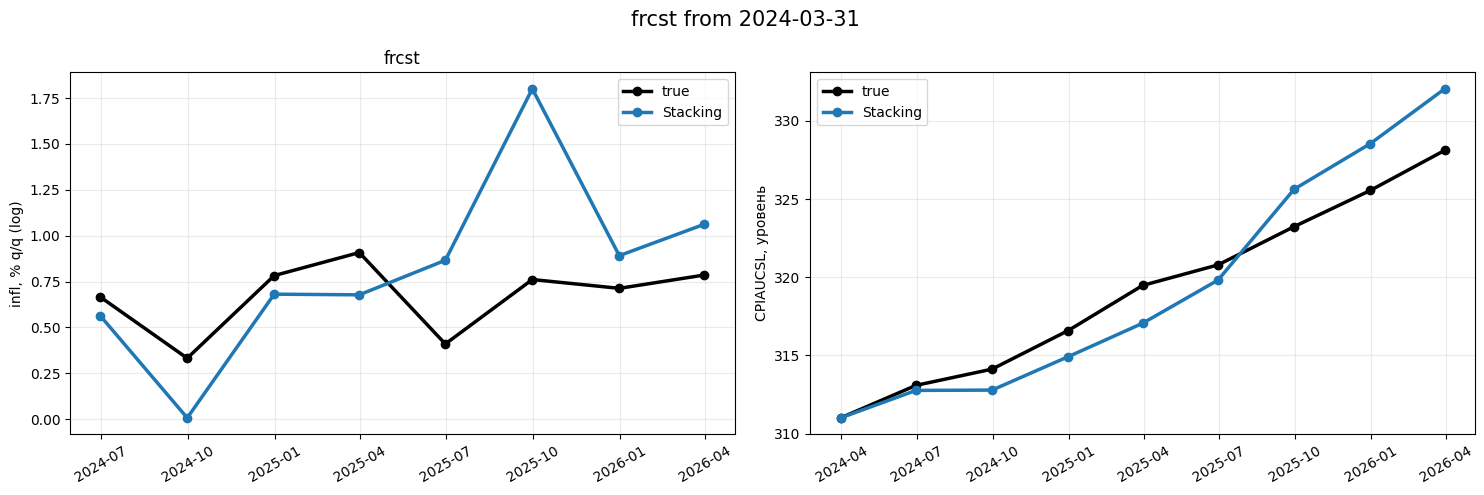

In [12]:
trajectory = stacking_oof[stacking_oof.origin.eq(train_end)].sort_values('horizon').copy()
cpi_level = df_full.assign(Date=pd.to_datetime(df_full.Date)).set_index('Date').CPIAUCSL.astype(float)
trajectory['level_true'] = cpi_level.reindex(trajectory.Date).to_numpy()
trajectory['level_pred'] = cpi_level.loc[train_end] * np.exp(trajectory.y_pred.cumsum())
trajectory.to_csv(STACKING_DIR / 'stacking_trajectory.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(trajectory.Date, 100 * trajectory.y_true, 'o-', color='black', lw=2.5, label='true')
axes[0].plot(trajectory.Date, 100 * trajectory.y_pred, 'o-', color='tab:blue', lw=2.5, label='Stacking')
axes[0].set_ylabel('infl, % q/q (log)'); axes[0].set_title('frcst')

level_dates = pd.Index([train_end, *trajectory.Date])
axes[1].plot(level_dates, cpi_level.reindex(level_dates), 'o-', color='black', lw=2.5, label='true')
axes[1].plot(level_dates, [cpi_level.loc[train_end], *trajectory.level_pred], 'o-', color='tab:blue', lw=2.5, label='Stacking')
axes[1].set_ylabel('CPIAUCSL, уровень'); axes[1].set_title('')
for ax in axes: ax.grid(alpha=.25); ax.legend(); ax.tick_params(axis='x', rotation=30)
fig.suptitle(f'frcst from {train_end.date()}', fontsize=15)
plt.tight_layout(); fig.savefig(STACKING_DIR / 'stacking_trajectory.png', dpi=160, bbox_inches='tight'); plt.show()

## Волосатый график: до 4 кварталов вперёд

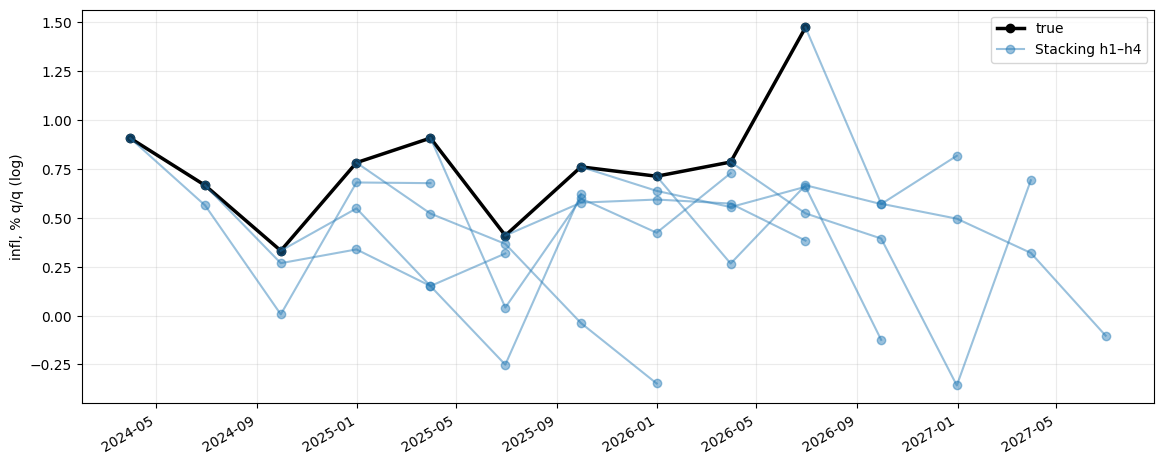

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
actual = data_full.loc[data_full.index >= train_end, 'CPIAUCSL']
ax.plot(actual.index, 100 * actual, 'o-', color='black', lw=2.5, label='true')
origins = weighted_full[1].index[weighted_full[1].index >= train_end]
for i, origin in enumerate(origins):
    hs = [h for h in range(1, 5) if origin in weighted_full[h].index]
    dates = [origin + pd.offsets.QuarterEnd(h) for h in hs]; pred = [weighted_full[h].loc[origin] for h in hs]
    ax.plot([origin, *dates], 100 * np.r_[data_full.loc[origin, 'CPIAUCSL'], pred], 'o-', color='tab:blue', alpha=.45, label='Stacking h1–h4' if i == 0 else None)
ax.set_ylabel('infl, % q/q (log)'); ax.set_title('', pad=12); ax.grid(alpha=.25); ax.legend()
fig.autofmt_xdate(); plt.tight_layout(pad=2); fig.savefig(STACKING_DIR / 'stacking_hairplot_h4.png', dpi=160, bbox_inches='tight'); plt.show()

In [10]:
print('Веса:', *(STACKING_DIR / f'stacking_weights_h{h}.pkl' for h in range(1, 9)), sep='\n')
print('\nОбщий словарь:', STACKING_DIR / 'stacking_weights_all.pkl')
print('График:', STACKING_DIR / 'stacking_trajectory.png')

Веса:
models/stacking/stacking_weights_h1.pkl
models/stacking/stacking_weights_h2.pkl
models/stacking/stacking_weights_h3.pkl
models/stacking/stacking_weights_h4.pkl
models/stacking/stacking_weights_h5.pkl
models/stacking/stacking_weights_h6.pkl
models/stacking/stacking_weights_h7.pkl
models/stacking/stacking_weights_h8.pkl

Общий словарь: models/stacking/stacking_weights_all.pkl
График: models/stacking/stacking_trajectory.png
